# Customer Personality Analysis
Name: CC Liang

Group Number and Name: G11 - CWL2

Group Members: Wendi Ke, Jinghan Zhang, and Bowen Cui

In [20]:
# load the libraries for data cleaning, wrangling, and modelling
library(tidyverse)
library(car)
library(broom)

## Planning Stage: Data Description & Exploratory Data Analysis (individual assignment 1)

###  1. Data Description
Customer Personality Analysis helps a company understand its ideal customers by examining their needs, behaviours, and concerns. While this dataset was originally collected to summarize customer segments using clustering, we could also investigate catalogue purchasing behaviours specifically. Despite the prevalence of e-commerce, catalogue shopping is a unique, significant channel that enhances cost optimization, streamlines operations, and improves visibility and control (GEP, 2024). The dataset contains the key variable `NumCatalogPurchases`, or the number of purchases made using a catalogue, alongside a rich set of potential predictors related to `People` and `Products`.

##### 3a. Load the dataset

Next, I'll read the dataset. Since we uploaded the dataset to our GitHub repository, we can read the CSV file from our GitHub link. However, please note that while the given dataset is in CSV format, it is actually a tab-separated values, or TSV. That said, we'll use `read_tsv` to read the dataset, and everything will be stored properly in a dataframe.

In [3]:
customer_personality_analysis <- 
    read_tsv("https://raw.githubusercontent.com/wend1k3/CWL2-STAT-301/main/marketing_campaign.csv")
head(customer_personality_analysis)

Rows: 2240 Columns: 29
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (3): Education, Marital_Status, Dt_Customer
dbl (26): ID, Year_Birth, Income, Kidhome, Teenhome, Recency, MntWines, MntF...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,⋯,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5524,1957,Graduation,Single,58138,0,0,04-09-2012,58,635,⋯,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344,1,1,08-03-2014,38,11,⋯,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613,0,0,21-08-2013,26,426,⋯,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646,1,0,10-02-2014,26,11,⋯,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293,1,0,19-01-2014,94,173,⋯,5,0,0,0,0,0,0,3,11,0
7446,1967,Master,Together,62513,0,1,09-09-2013,16,520,⋯,6,0,0,0,0,0,0,3,11,0


##### a. The Number of Observations and Variables
We can use `dim()` to retrieve the dimension of dataset, including both the numbers of rows and columns.

In [4]:
dim(customer_personality_analysis)

[1] 2240   29

This tells us that `customer_personality_analysis` has 2240 rows or observations, as well as 29 columns or variables.

##### b. Names and Types of Variables
We can use `glimpse()` to understand the variables. In particular, it provides the name, type, and sample value for each variable.

In [5]:
glimpse(customer_personality_analysis)

Rows: 2,240
Columns: 29
$ ID                  <dbl> 5524, 2174, 4141, 6182, 5324, 7446, 965, 6177, 485…
$ Year_Birth          <dbl> 1957, 1954, 1965, 1984, 1981, 1967, 1971, 1985, 19…
$ Education           <chr> "Graduation", "Graduation", "Graduation", "Graduat…
$ Marital_Status      <chr> "Single", "Single", "Together", "Together", "Marri…
$ Income              <dbl> 58138, 46344, 71613, 26646, 58293, 62513, 55635, 3…
$ Kidhome             <dbl> 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,…
$ Teenhome            <dbl> 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,…
$ Dt_Customer         <chr> "04-09-2012", "08-03-2014", "21-08-2013", "10-02-2…
$ Recency             <dbl> 58, 38, 26, 26, 94, 16, 34, 32, 19, 68, 11, 59, 82…
$ MntWines            <dbl> 635, 11, 426, 11, 173, 520, 235, 76, 14, 28, 5, 6,…
$ MntFruits           <dbl> 88, 1, 49, 4, 43, 42, 65, 10, 0, 0, 5, 16, 61, 2, …
$ MntMeatProducts     <dbl> 546, 6, 127, 20, 118, 98, 164, 56, 24, 6, 6, 11, 4…
$ MntFishProduct

From the results, we can see that most of the variables are double (dbl), with three variables in the type of characters (chr), namely `Education`, `Marital_Status`, and `Dt_Customer`.

##### c. Data Collection

It was explained in the dataset description that the data was provided by Dr. Omar Romero-Hernandez. Both complaints filed, and the amount spent on certain products refer to the last two years prior to the time of collection. I assume the data was collected by a company and used internally to analyze customer trends. Given the variables, which include customer demographics, purchase history, and responses to marketing campaigns, I also assume the data was pulled from a database or CRM system, rather than gathered through surveys. Each observation represents a customer, and each has been randomly assigned an `ID` to ensure anonymity.

##### d. Data Source and Citation
Dataset from https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

The dataset for this project is provided by Dr. Omar Romero-Hernandez.

### 2. Question

The question I want to answer is "Are customers’ purchasing behaviors associated with the number of catalog purchases they make, after accounting for demographic characteristics?", given that the dataset includes a variety of purchasing behaviour variables and demographic information. In this inference question, where I aim to examine the associations between purchasing behavior and catalog purchases rather than to predict future outcomes, the response variable would be `NumCatalogPurchases`, as indicated in our project requirement, and the covariates I anticipate to be most important include `NumDealsPurchases` and `NumStorePurchases`, along with demographic characteristics such as `Education` and `Marital_Status`. Demographic variables will be included as control variables, while other variables unrelated to the question, such as Campaign Accepted and the amount of certain products purchased, will not be used in the analysis.

### 3. Exploratory Data Analysis and Visualization

##### a. Loading the Dataset
The dataset was loaded earlier in part 1 to obtain data information.

##### b. Cleaning and Wrangling
The dataset is fairly cleaned. The only issue I noticed from the data description section is that the `ID` column is in the type of double (dbl) though they should be categorical. Therefore, I'll turn in into a character/factor.

In [6]:
customer_personality_analysis <- customer_personality_analysis |>
    mutate(ID = as.character(ID))

##### c. Missing Values
I would start by checking if there is any missing values in the dataset using `sum()` and `is.na()`.

In [7]:
sum(is.na(customer_personality_analysis))

[1] 24

As seen, there are 24 NA values. My next step is to figure out the numbers and percentages of missing values in each variable.

In [8]:
# See 3f for AI tool usage
missing_summary <- data.frame(
    count = colSums(is.na(customer_personality_analysis)),
    percent = colMeans(is.na(customer_personality_analysis)) * 100) |>
    arrange(desc(percent))

head(missing_summary)

,count,percent
,<dbl>,<dbl>
Income,24,1.071429
ID,0,0.000000
Year_Birth,0,0.000000
Education,0,0.000000
Marital_Status,0,0.000000
Kidhome,0,0.000000


As seen in the table above, `Income` is the only variable with NA values. It has 24 values, which accounts for just over 1% of the dataset. In other words, there is no variable with a large proportion of missing data.

##### d. Class Imbalance
Looking at the dataset, there are two categorical variables that I will need to check: `Education` and `Marital_Status`. Although `Dt_Customer` is a character, it is the date of customer's enrollment with the company, which is rather continuous and does not form a class.

I'll start by checking the distribution for `Education`, using `prop.table()`.

In [9]:
prop.table(table(customer_personality_analysis$Education))


  2n Cycle      Basic Graduation     Master        PhD 
0.09062500 0.02410714 0.50312500 0.16517857 0.21696429 

There is a class imbalance. Notably, the 'Graduation' category takes up over 50% of the variable, while the categories '2n Cycle' and 'Basic' are underrepresented with 9% and 2%, respectively.

Next, I'll check class imblance for `Martial_Status` using the same procedure.

In [10]:
prop.table(table(customer_personality_analysis$Marital_Status))


      Absurd        Alone     Divorced      Married       Single     Together 
0.0008928571 0.0013392857 0.1035714286 0.3857142857 0.2142857143 0.2589285714 
       Widow         YOLO 
0.0343750000 0.0008928571 

There is also a class imbalance for `Martial_Status`. The 'Married' category takes up 39% among 8 categories, while 'Absurd' and 'YOLO' are severely underrepresented. For the purpose of data visualization and analysis in future stages, it may be worthwhile to address class imbalance by either combining minority categories or using techniques to oversample them.

##### e. Visualization
Given the presence of various categorical levels and class imbalance in `Education` and `Marital_Status`, I will first combine some groups to ensure adequate representation. For `Education`, I'm split between post-graduate and non-post-graduate. In other words, I'll combine 'Basic' and 'Graduation' into one category, leaving the other three as a separate one. For `Marital_Status`, 'Married,' 'Single,' and 'Together' are fairly well represented, so the remaining levels (e.g., Divorced, Widow, Alone) will be combined into an 'Other' category.

In [11]:
with_demographic_groups <- customer_personality_analysis %>%
    mutate(
        Education_Group = case_when(
            Education %in% c("Basic", "Graduation") ~ "Graduation",
            Education %in% c("2n Cycle", "Master", "PhD") ~ "Post-Graduate",
            TRUE ~ Education
        ),
        Marital_Group = case_when(
            Marital_Status == "Married" ~ "Married",
            Marital_Status == "Single" ~ "Single",
            Marital_Status == "Together" ~ "Together",
            TRUE ~ "Other"
        ))

To explore the relationship between purchasing behaviors and the number of catalog purchases, while accounting for demographic characteristics, I selected the covariate I expect to be most useful and built a scatterplot accordingly. I applied `facet_wrap()` to `Education_Group`, as it has fewer categories than `Marital_Group`, which is represented using different colors. A simple scatterplot with a linear regression line provides a clear view of the overall trend.

I believe that this visualization is relevant to address my question because it allows me to easily understand if there are differences between each group and the relationship between the predictors and the response variable. It is important to understand whether there is a linear relationship between variables.

`geom_smooth()` using formula = 'y ~ x'


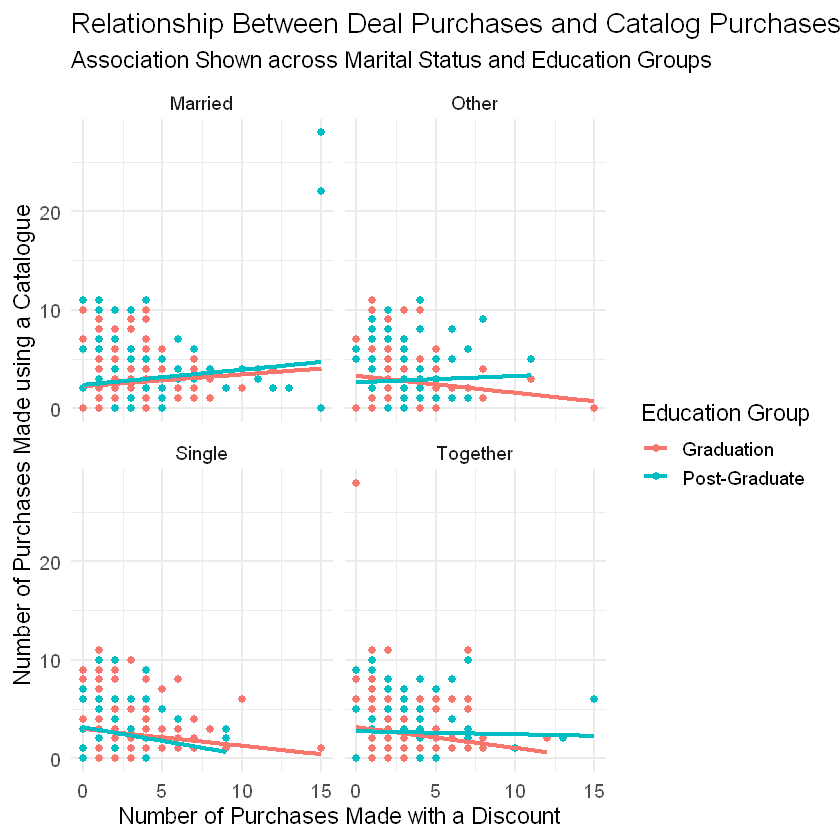

In [12]:
customer_personality_visualization <- with_demographic_groups |>
    ggplot(aes(x = NumDealsPurchases,
               y = NumCatalogPurchases,
               color = Education_Group)) +
    geom_point() +
    geom_smooth(method = "lm", se = FALSE) +
    facet_wrap(~Marital_Group) +
    theme_minimal(base_size = 14) +
    labs(
        x = "Number of Purchases Made with a Discount",
        y = "Number of Purchases Made using a Catalogue",
        title = "Relationship Between Deal Purchases and Catalog Purchases",
        subtitle = "Association Shown across Marital Status and Education Groups",
        color = "Education Group")

customer_personality_visualization

Preliminary visualization suggests that there may exist an association between the number of deal purchases and catalog purchases, with this relationship appearing across multiple marital status and education groups. However, there are significant differences across groups. The "Married" `Marital_Group` shows the most robust positive trend, and the correlation is consistent for both `Education_Group`. On the other hand, the "Single" `Marital_Group` shows the opposite trend, with both `Education_Group` displaying a negative correlation between the two factors. Whereas these two groups display similar trends between `Education_Group`, this is not the case for the "Other" `Marital_Group`, which features one positive and one negative correlation. In short, variability in both the strength and level of this association across demographic groups indicates that these factors may be associated with catalog purchasing behaviours, but a formal data analysis is needed to assess these relationships while controlling for demographic characteristics。

##### f. AI Tool Disclosure

Most of the assignment is completed without AI usage. However, for 3c, I struggled with calculating the count and percentage of NA values for each variable. Therefore, I asked ChatGPT-4o for help, and it taught me about `colSums()` and `colMeans()`. I then typed `?colSums` in the Jupyter Notebook to read the R documentation (Information relating to `colMeans()` is provided on the same page). I wrote my code after reading the documentation.

### References
Procurement Software. (2024, March 28). Catalog management in procurement: Its benefits and best practices: GEP blog. Catalog Management in Procurement: Its Benefits and Best Practices | GEP Blog. https://www.gep.com/blog/technology/catalog-management-in-procurement-benefits-best-practices 

## Methods and Plan & Computational Code and Output (individual assignment 2)

### 1. Methods and Plan

##### 1b. Proposed Method
I propose using a Poisson regression model with `NumCatalogPurchases` as the response variable, and predictors including different purchasing behaviours and demographic variables.

This method is appropriate because the response variable is a count (non-negative integer), and Poisson models are for count data. Although the relationship between the response variables and different predictors may differ, having an additive model would make the interpretations significantly easier.

##### 1c. Assumptions and Limitations
*Assumptions*

- Distribution: The response variable follows a Poisson distribution, meaning the mean equals the variance
- Independence: Observations are independent of each other.
- Multicollinearity: Predictors should not be highly correlated, as this can lead to unstable coefficient estimates and difficulty in interpretation.
- Linearity (on log scale): The log of the expected value of the response variable is a linear combination of the predictors.
- Additive model: It is assumed that the relationship between each predictor and the response variable shares the same slope.

*Limitations*
- Poisson is an associational model and cannot provide any causal claim.
- Overdispersion is common in count data, so the Poisson assumption of equal mean and variance may be violated. This results in underestimated standard errors.
- Coefficients are interpreted on the log scale and require transformation for practical interpretation, which may reduce interpretability.
- There may be factors, such as income or recency, not included in the model that influence catalog purchases. These confounding factors, if they exist, will prevent us from making a comprehensive conclusion. 

### 2. Computational Code and Output

##### 2a. Computation Code

The poisson model includes every variable relating to purchasing behaviours and demographic characteristics. In particular, the purchasing behaviours predictors are `NumDealsPurchases`, `NumStorePurchases`, `NumWebPurchases`, and `NumWebVisitsMonth`, while the demographic characteristics are `Education`, `Marital_Status`, `Kidhome`, `Teenhome`, and `Income`.

In [27]:
customer_personality_poisson <- glm(formula = NumCatalogPurchases ~ NumDealsPurchases + NumStorePurchases + NumWebPurchases + NumWebVisitsMonth + 
                                    Education + Marital_Status + Kidhome + Teenhome + Income, 
                                    data = with_demographic_groups, 
                                    family = "poisson")

Before interpreting the results, I'll need to check for multicollinearity and overdispersion.

In [28]:
vif(customer_personality_poisson)

,GVIF,Df,GVIF^(1/(2*Df))
NumDealsPurchases,1.407854,1,1.186530
NumStorePurchases,1.167757,1,1.080628
NumWebPurchases,1.197435,1,1.094274
NumWebVisitsMonth,1.697995,1,1.303072
Education,1.073524,4,1.008908
Marital_Status,1.068468,7,1.004742
Kidhome,1.474120,1,1.214133
Teenhome,1.453654,1,1.205676
Income,1.131967,1,1.063940


As all VIF values are below 2, there is no indication of multicollinearity.

In [29]:
dispersion_ratio <- deviance(customer_personality_poisson) / df.residual(customer_personality_poisson)
dispersion_ratio 

[1] 1.27674

A ratio of 1.28 indicates mild overdispersion, meaning that variance in catalog purchases exceeds the Poisson model's assumed mean-variance equality. This leads to underestimated standard errors for some predictors and thus p-values that are slightly too small.

##### 2b. Visualization

In [30]:
tidy_customer_personality_poisson <- tidy(customer_personality_poisson, exponentiate = TRUE)
tidy_customer_personality_poisson

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),2.8126089,2.660482e-01,3.8869361,1.015175e-04
NumDealsPurchases,1.1387958,6.491770e-03,20.0209550,3.617212e-89
NumStorePurchases,1.0437129,4.235422e-03,10.1015843,5.435686e-24
NumWebPurchases,1.0830588,4.526794e-03,17.6259947,1.556075e-69
NumWebVisitsMonth,0.8614945,7.269125e-03,-20.5095704,1.768493e-93
EducationBasic,0.5199838,2.034298e-01,-3.2146610,1.305987e-03
EducationGraduation,1.0642446,4.968797e-02,1.2531260,2.101599e-01
EducationMaster,1.0161122,5.675621e-02,0.2816217,7.782336e-01
EducationPhD,1.0647901,5.360739e-02,1.1710636,2.415732e-01


##### 2c. Interpretation
All purchasing behaviours are statistically significantly associated with the number of catalog purchases (all $p < 0.0001$): a one-unit increase in deals purchased is associated with a (1.139 - 1) * 100% = 13.9% higher mean count, holding all other variables constant; store and web purchases show similar positive effects (1.044 -1) * 100% = 4.4% and (1.083 - 1) * 100% = 8.3%, respectively), while one additional web visit per month is associated with a (0.861 - 1) * 100% = 13.9% lower mean count. Among demographic predictors, kids at home ((0.427 - 1) * 100% = ‑57.3%) and teens at home ((0.713 - 1) * 100% = ‑28.7%) are strong predictors, whereas education and marital status, to my surprise, show mostly statistically‑significant effects compared to the reference levels. The model exhibits mild overdispersion (≈1.28), meaning variance slightly exceeds the Poisson assumption of equality with the mean, and it may be helpful to consider using the quasilikelihood method. Nevertheless, the extremely small p‑values for key predictors (`NumDealsPurchases`, `NumStorePurchases`, `NumStorePurchases`, `NumWebVisitsMonth`, `Kidhome`, and `Teenhome`) indicate these relationships are clearly associated and detectable without correcting for overdispersion.